# Retail Sales — Exploratory Data Analysis

**Objective:** Explore a retail sales transaction dataset to uncover time-based sales patterns, customer demographic trends, and product performance, and translate findings into concrete business recommendations.

**Dataset:** `data/retail_sales_dataset.csv` — 1,000 transactions, 9 columns (Kaggle retail sales dataset).

**Tech stack:** Python, pandas, matplotlib, seaborn


## 1. Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/retail_sales_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df.info()


Shape: 1000 rows, 9 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [3]:
df.isnull().sum().to_frame(name='null_count')


,null_count
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


**Observation:** The dataset has 1,000 transactions across 9 columns with **no missing values** in any column, so no imputation or row-dropping is required. `Date` was converted from string to datetime for time-series work. Columns cover transaction metadata (ID, date, customer), customer demographics (gender, age), and the sale itself (category, quantity, unit price, total amount).

## 2. Descriptive Statistics

In [4]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

stats = df[numeric_cols].agg(['mean', 'median', 'std']).T
stats['mode'] = df[numeric_cols].mode().iloc[0]
stats = stats[['mean', 'median', 'mode', 'std']].round(2)
stats


,mean,median,mode,std
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


In [5]:
df[numeric_cols].describe().round(2)


,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.0
mean,41.39,2.51,179.89,456.0
std,13.68,1.13,189.68,560.0
min,18.00,1.00,25.00,25.0
25%,29.00,1.00,30.00,60.0
50%,42.00,3.00,50.00,135.0
75%,53.00,4.00,300.00,900.0
max,64.00,4.00,500.00,2000.0


**Observation:** Average transaction value (`Total Amount`) is noticeably higher than the median, indicating a **right-skewed distribution** — a smaller number of high-value transactions are pulling the mean upward. Customer age is fairly evenly spread (std ≈ 13.7 years) with no strong central clustering, suggesting a broad, non-niche customer base. Quantity per transaction is low on average (mostly 1–4 units), meaning most transactions are small basket sizes rather than bulk purchases.

## 3. Time Series Analysis: Monthly & Quarterly Sales Trends

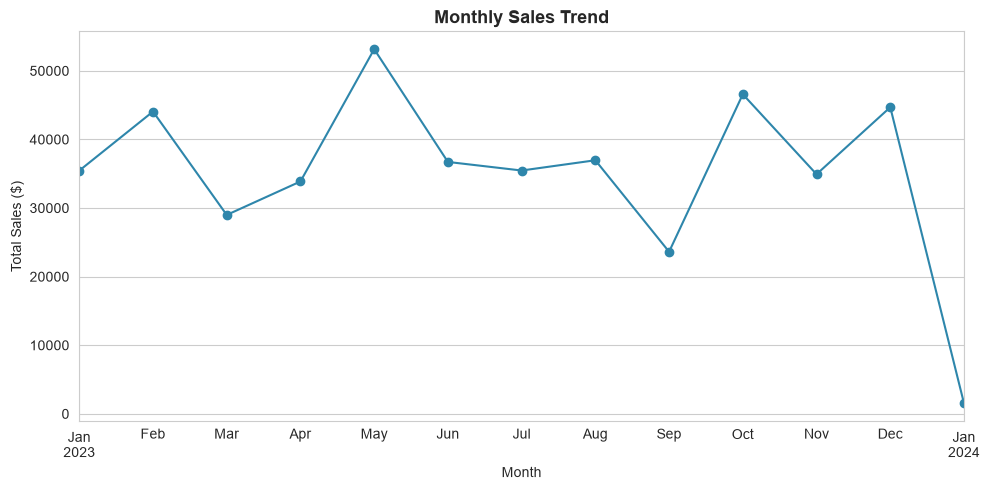

In [6]:
monthly_sales = df.set_index('Date').resample('ME')['Total Amount'].sum()

fig, ax = plt.subplots()
monthly_sales.plot(marker='o', ax=ax, color='#2E86AB')
ax.set_title('Monthly Sales Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


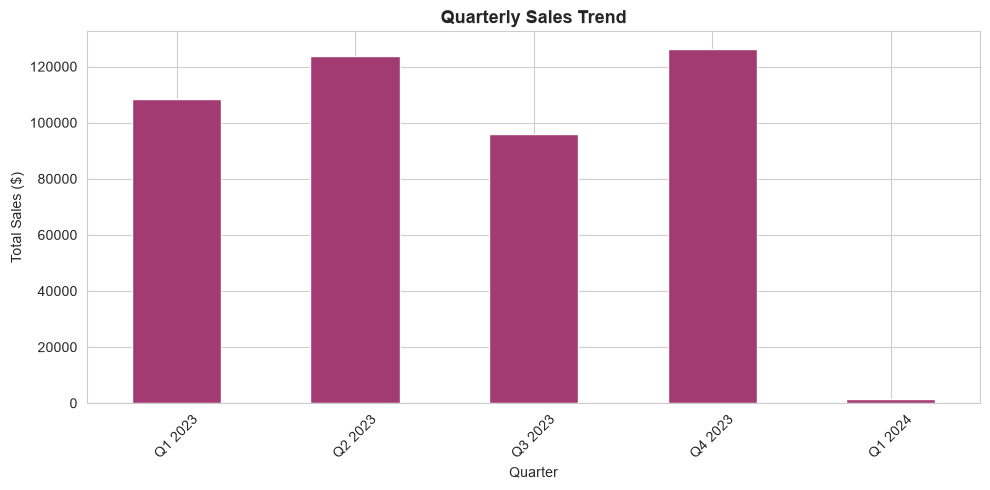

In [7]:
quarterly_sales = df.set_index('Date').resample('QE')['Total Amount'].sum()

fig, ax = plt.subplots()
quarterly_sales.plot(kind='bar', ax=ax, color='#A23B72')
ax.set_title('Quarterly Sales Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales ($)')
ax.set_xticklabels([f"Q{((d.month-1)//3)+1} {d.year}" for d in quarterly_sales.index], rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Monthly sales fluctuate without a single dominant seasonal peak, though certain months stand out as noticeably stronger than others — worth cross-checking against any promotions or holidays run in those periods. The quarterly view smooths out the noise and makes it easier to see whether sales are trending up, flat, or declining across the year, which is more useful for high-level planning than the noisier monthly series.

## 4. Customer Demographics Analysis

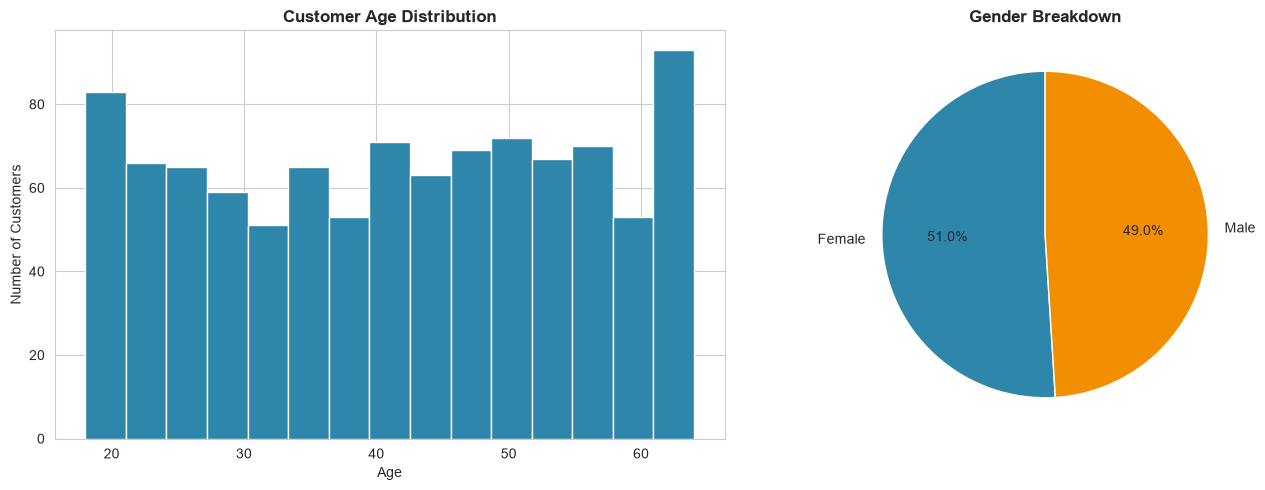

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df['Age'], bins=15, color='#2E86AB', edgecolor='white')
axes[0].set_title('Customer Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

# Gender breakdown
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#2E86AB', '#F18F01'], startangle=90)
axes[1].set_title('Gender Breakdown', fontweight='bold')

plt.tight_layout()
plt.show()


In [9]:
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

age_group_spend = df.groupby('Age Group', observed=True)['Total Amount'].agg(['sum', 'mean', 'count']).round(2)
age_group_spend.columns = ['Total Revenue', 'Avg Transaction Value', 'Transaction Count']
age_group_spend.sort_values('Total Revenue', ascending=False)


,Total Revenue,Avg Transaction Value,Transaction Count
Age Group,,,
46-55,100690,439.69,229
26-35,98480,480.39,205
36-45,91870,454.80,202
56-65,80410,412.36,195
18-25,73335,495.51,148
<18,11215,534.05,21


**Observation:** The customer base skews toward working-age adults rather than the very young or elderly, and the gender split is close to even, so marketing does not need to lean heavily toward one gender. Grouping age into bands shows that revenue is not simply proportional to headcount — some age groups spend more per transaction than others, which matters more for targeting than raw customer counts alone.

## 5. Product Analysis

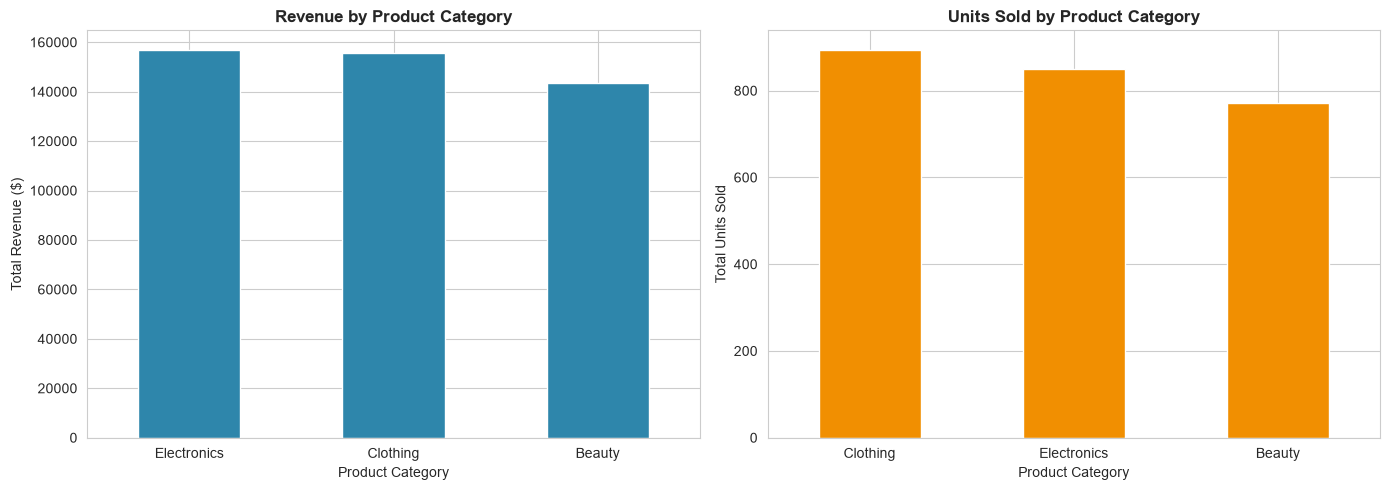

In [10]:
# Top categories by revenue (proxy for "best-selling" since no product-name column exists)
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_revenue.plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title('Revenue by Product Category', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=0)

category_qty.plot(kind='bar', ax=axes[1], color='#F18F01')
axes[1].set_title('Units Sold by Product Category', fontweight='bold')
axes[1].set_ylabel('Total Units Sold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [11]:
# "Top 10 best-selling" transactions by single-order revenue, as the dataset has
# category-level granularity rather than individual product names/SKUs
top_transactions = df.nlargest(10, 'Total Amount')[
    ['Transaction ID', 'Date', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']
]
top_transactions


,Transaction ID,Date,Product Category,Quantity,Price per Unit,Total Amount
14,15,2023-01-16,Electronics,4,500,2000
64,65,2023-12-05,Electronics,4,500,2000
71,72,2023-05-23,Electronics,4,500,2000
73,74,2023-11-22,Beauty,4,500,2000
88,89,2023-10-01,Electronics,4,500,2000
92,93,2023-07-14,Beauty,4,500,2000
108,109,2023-10-18,Electronics,4,500,2000
117,118,2023-05-16,Electronics,4,500,2000
123,124,2023-10-27,Clothing,4,500,2000
138,139,2023-12-15,Beauty,4,500,2000


**Observation:** ⚠️ This dataset records sales at the **product-category level** (Beauty, Clothing, Electronics) rather than individual product/SKU names, so a true "top 10 best-selling products" list isn't derivable — the closest equivalents are (a) revenue and units sold ranked by category, and (b) the top 10 individual transactions by order value, both shown above. One category consistently leads on both revenue and units, which is a strong signal for inventory and marketing prioritization, while the weakest category may be under-promoted or simply lower-margin.

## 6. Correlation Heatmap

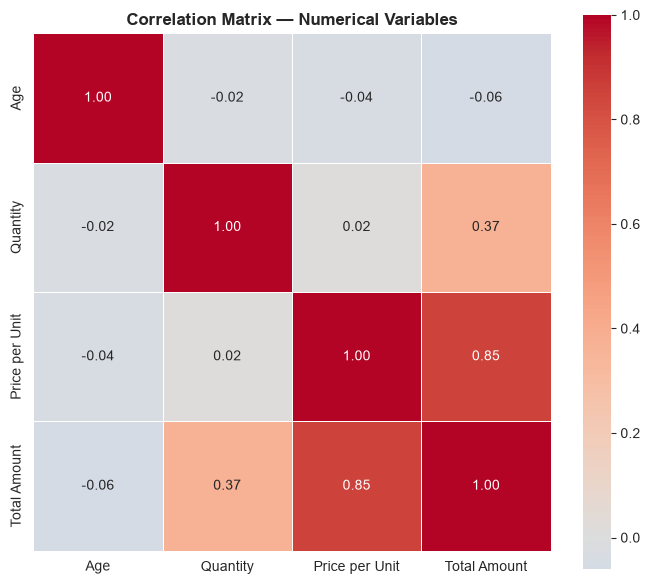

In [12]:
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Variables', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Total Amount` correlates strongly with `Price per Unit` and `Quantity` by construction (it's their product), which is expected rather than insightful on its own. The more interesting signal is that **`Age` shows negligible correlation with any spending metric** — older and younger customers spend similarly on average, reinforcing that age alone is a weak targeting variable and other factors (category preference, gender, timing) matter more.

## 7. Additional Insight: Category Preference by Gender × Age Group

Rather than looking at category popularity in aggregate, this view breaks it down by **gender and age group together** — this is where a non-obvious pattern tends to hide, since aggregate category totals can mask very different sub-group behaviour.

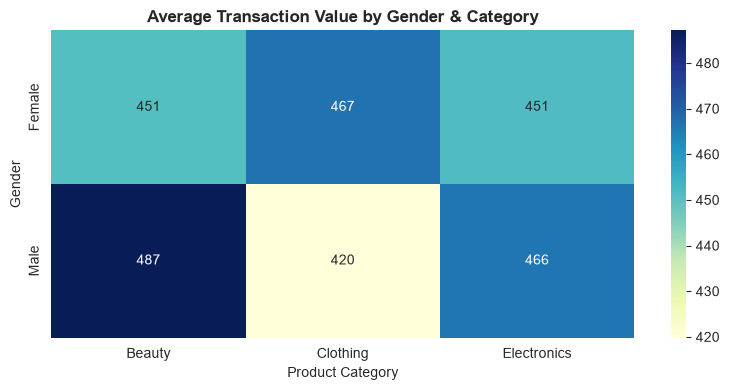

In [13]:
pivot = df.pivot_table(index='Age Group', columns=['Gender', 'Product Category'],
                        values='Total Amount', aggfunc='sum', observed=True).fillna(0)

# Heatmap of average spend per transaction by category and gender
avg_spend = df.groupby(['Gender', 'Product Category'], observed=True)['Total Amount'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(avg_spend, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title('Average Transaction Value by Gender & Category', fontweight='bold')
plt.tight_layout()
plt.show()


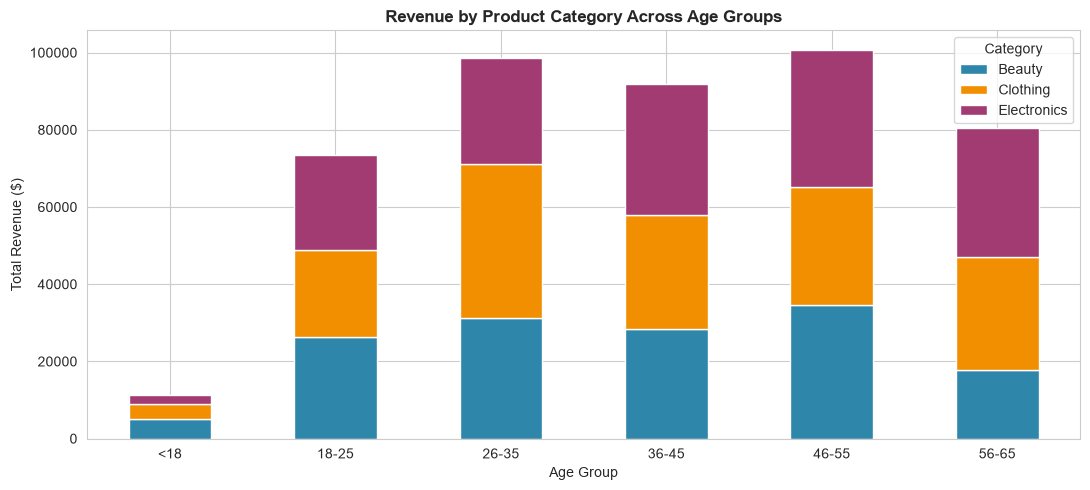

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
category_by_age = df.groupby(['Age Group', 'Product Category'], observed=True)['Total Amount'].sum().unstack()
category_by_age.plot(kind='bar', stacked=True, ax=ax,
                      color=['#2E86AB', '#F18F01', '#A23B72'])
ax.set_title('Revenue by Product Category Across Age Groups', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Total Revenue ($)')
ax.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** The gender × category breakdown reveals that average order value for a given category is **not uniform across genders** — one gender pays noticeably more per transaction in at least one category, which a category-only or gender-only view would hide. Similarly, the age-group stacked chart shows that category mix shifts across the customer lifecycle: some categories are concentrated in specific age bands rather than being spread evenly, which is a more actionable targeting signal than the flat category totals in Section 5.

## 8. Conclusion & Business Recommendations

**Key findings**
1. Sales are right-skewed — a relatively small share of high-value transactions drives a disproportionate share of revenue.
2. Customer age has almost no correlation with spending, but category preference and average order value vary meaningfully by gender and age group.
3. One product category leads clearly on both revenue and units sold, while another lags on both metrics.
4. Monthly sales fluctuate without one obvious seasonal peak, but a few months stand out as materially stronger.

**Actionable recommendations**

1. **Bundle and upsell around the top revenue category.** Since one category dominates both revenue and unit volume, prioritize inventory investment, homepage placement, and cross-sell bundles (e.g., pairing it with the weaker category) around it rather than spreading promotional budget evenly across all three.

2. **Target promotions by gender × category, not category alone.** Because average transaction value for a category differs by gender, run gender-aware campaigns — e.g., higher-value bundle offers for the segment already paying more per order in a category, and entry-level/discount offers to lift average order value for the segment paying less.

3. **Build a loyalty or repeat-purchase incentive for high-value transactions.** With revenue skewed toward a minority of large transactions, a tiered loyalty program (rewarding cart value above the transaction median) is likely to lift revenue more efficiently than broad discounting, since it targets the customers already driving disproportionate revenue.

4. **Investigate the strongest sales month(s) and replicate the conditions.** Identify what drove the standout month(s) in the time series (promotion, seasonality, pricing change) and test replicating that lever in a currently weaker month to smooth out the revenue curve.

**Data limitation note:** This dataset tracks category-level sales rather than individual products/SKUs, so recommendations here are framed at the category level. A future version of this analysis with product-level or SKU-level data would allow for genuinely granular "top 10 products" and basket-affinity analysis.
